In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Nombres de columnas según german.doc
columnas = [
    "estado_cuenta",          # A11-A14
    "duracion_meses",
    "historial_credito",      # A30-A34
    "proposito",              # A40-A410
    "monto_credito",
    "ahorros",                # A61-A65
    "empleo_actual",          # A71-A75
    "tasa_pago_pct_ingreso",
    "estado_civil_sexo",      # A91-A95
    "deudores_garantes",      # A101-A103
    "residencia_actual_anos",
    "propiedad",              # A121-A124
    "edad",
    "otros_planes_pago",      # A141-A143
    "vivienda",               # A151-A153
    "creditos_existentes",
    "trabajo",                # A171-A174
    "personas_a_cargo",
    "telefono",               # A191-A192
    "trabajador_extranjero",  # A201-A202
    "target"                  # 1=buen pagador, 2=mal pagador
]

df = pd.read_csv(
    "../data/raw/german.data",
    sep=" ",
    header=None,
    names=columnas
)

# Recodificamos el target: 1=mal pagador (positivo), 0=buen pagador
df["target"] = (df["target"] == 2).astype(int)

print(df.shape)
df.head()

(1000, 21)


,estado_cuenta,duracion_meses,historial_credito,proposito,monto_credito,ahorros,empleo_actual,tasa_pago_pct_ingreso,estado_civil_sexo,deudores_garantes,residencia_actual_anos,propiedad,edad,otros_planes_pago,vivienda,creditos_existentes,trabajo,personas_a_cargo,telefono,trabajador_extranjero,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())
print("\n=== Duplicados ===")
print(f"Filas duplicadas: {df.duplicated().sum()}")

=== Tipos de datos ===
estado_cuenta             object
duracion_meses             int64
historial_credito         object
proposito                 object
monto_credito              int64
ahorros                   object
empleo_actual             object
tasa_pago_pct_ingreso      int64
estado_civil_sexo         object
deudores_garantes         object
residencia_actual_anos     int64
propiedad                 object
edad                       int64
otros_planes_pago         object
vivienda                  object
creditos_existentes        int64
trabajo                   object
personas_a_cargo           int64
telefono                  object
trabajador_extranjero     object
target                     int64
dtype: object

=== Valores nulos por columna ===
estado_cuenta             0
duracion_meses            0
historial_credito         0
proposito                 0
monto_credito             0
ahorros                   0
empleo_actual             0
tasa_pago_pct_ingreso     0
estado_civi

In [ ]:
categoricas = df.select_dtypes(include="object").columns.tolist()
numericas = df.select_dtypes(include=np.number).columns.tolist()
numericas.remove("target")

print(f"Categóricas ({len(categoricas)}):")
print(categoricas)
print(f"\nNuméricas ({len(numericas)}):")
print(numericas)

Categóricas (13):
['estado_cuenta', 'historial_credito', 'proposito', 'ahorros', 'empleo_actual', 'estado_civil_sexo', 'deudores_garantes', 'propiedad', 'otros_planes_pago', 'vivienda', 'trabajo', 'telefono', 'trabajador_extranjero']

Numéricas (7):
['duracion_meses', 'monto_credito', 'tasa_pago_pct_ingreso', 'residencia_actual_anos', 'edad', 'creditos_existentes', 'personas_a_cargo']


In [5]:
df[numericas].describe().round(2)

,duracion_meses,monto_credito,tasa_pago_pct_ingreso,residencia_actual_anos,edad,creditos_existentes,personas_a_cargo
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


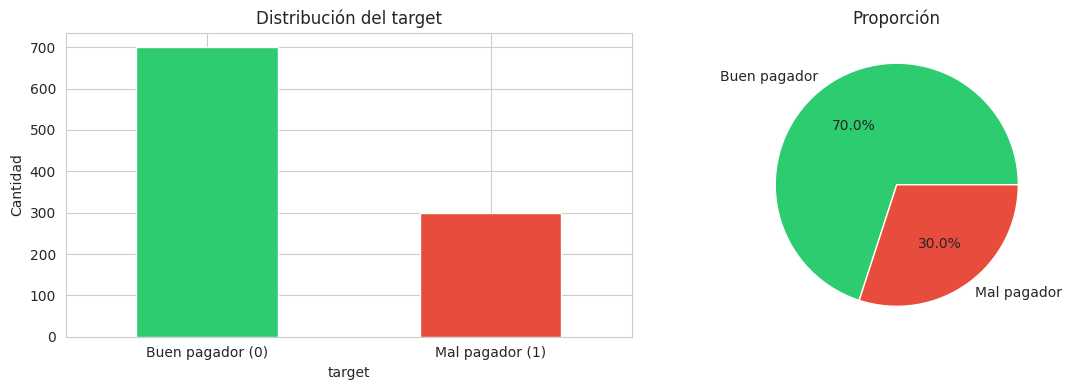


Ratio de desbalance: 1:2.33


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo absoluto
df["target"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"]
)
axes[0].set_title("Distribución del target")
axes[0].set_xticklabels(["Buen pagador (0)", "Mal pagador (1)"], rotation=0)
axes[0].set_ylabel("Cantidad")

# Proporción
df["target"].value_counts(normalize=True).plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    labels=["Buen pagador", "Mal pagador"]
)
axes[1].set_title("Proporción")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"\nRatio de desbalance: 1:{(df['target']==0).sum()/(df['target']==1).sum():.2f}")

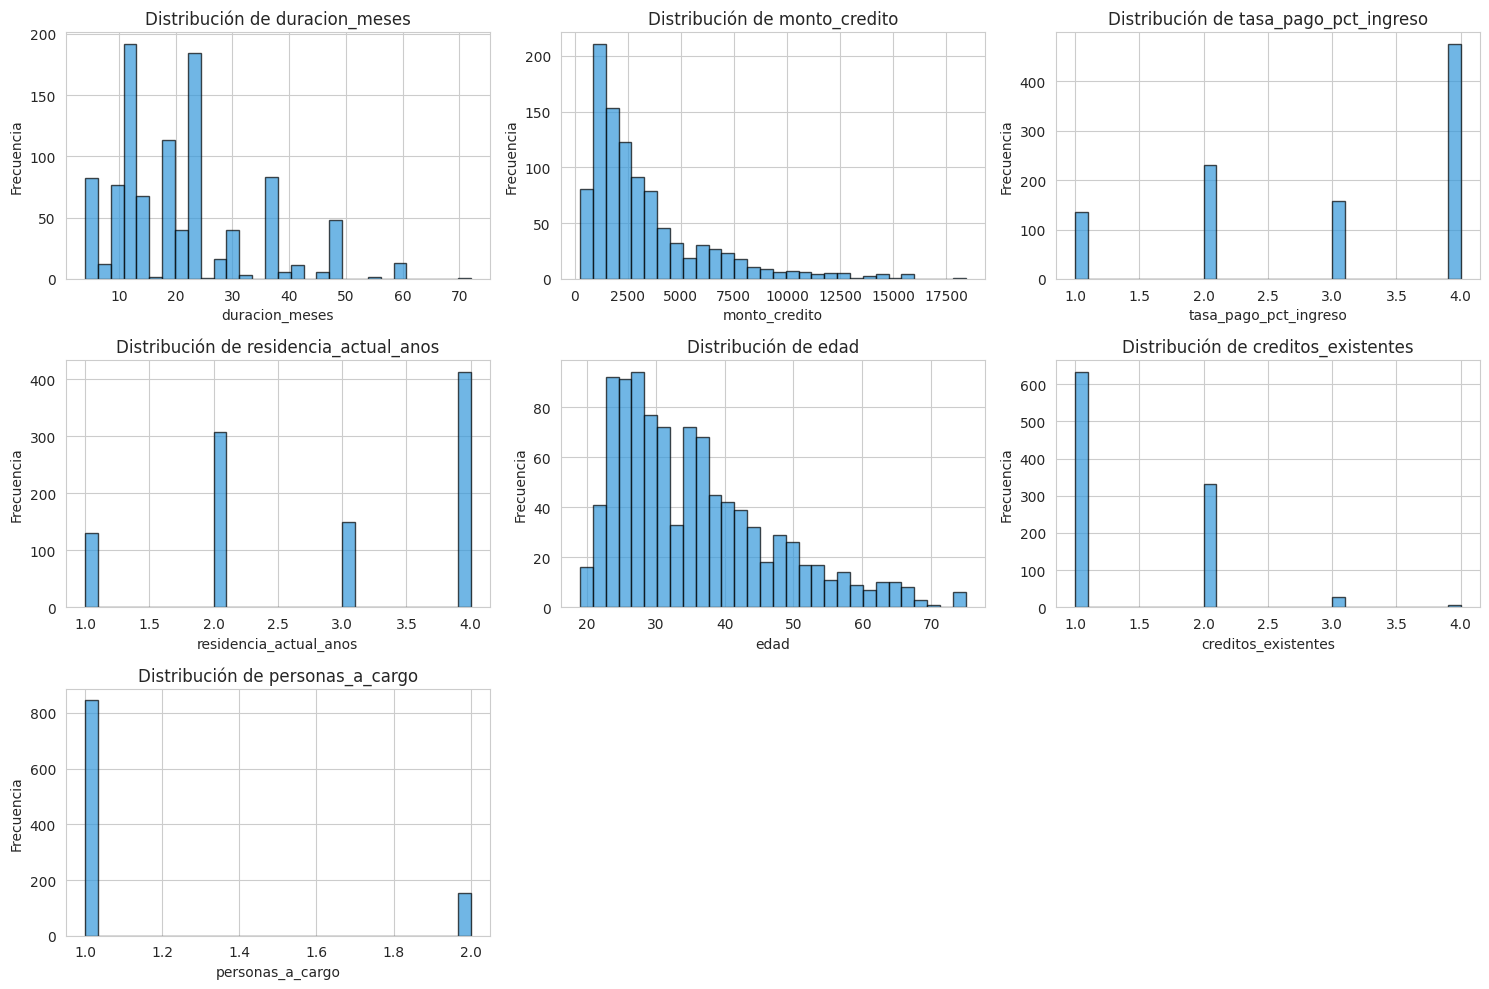

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col], bins=30, color="#3498db", edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

for j in range(len(numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

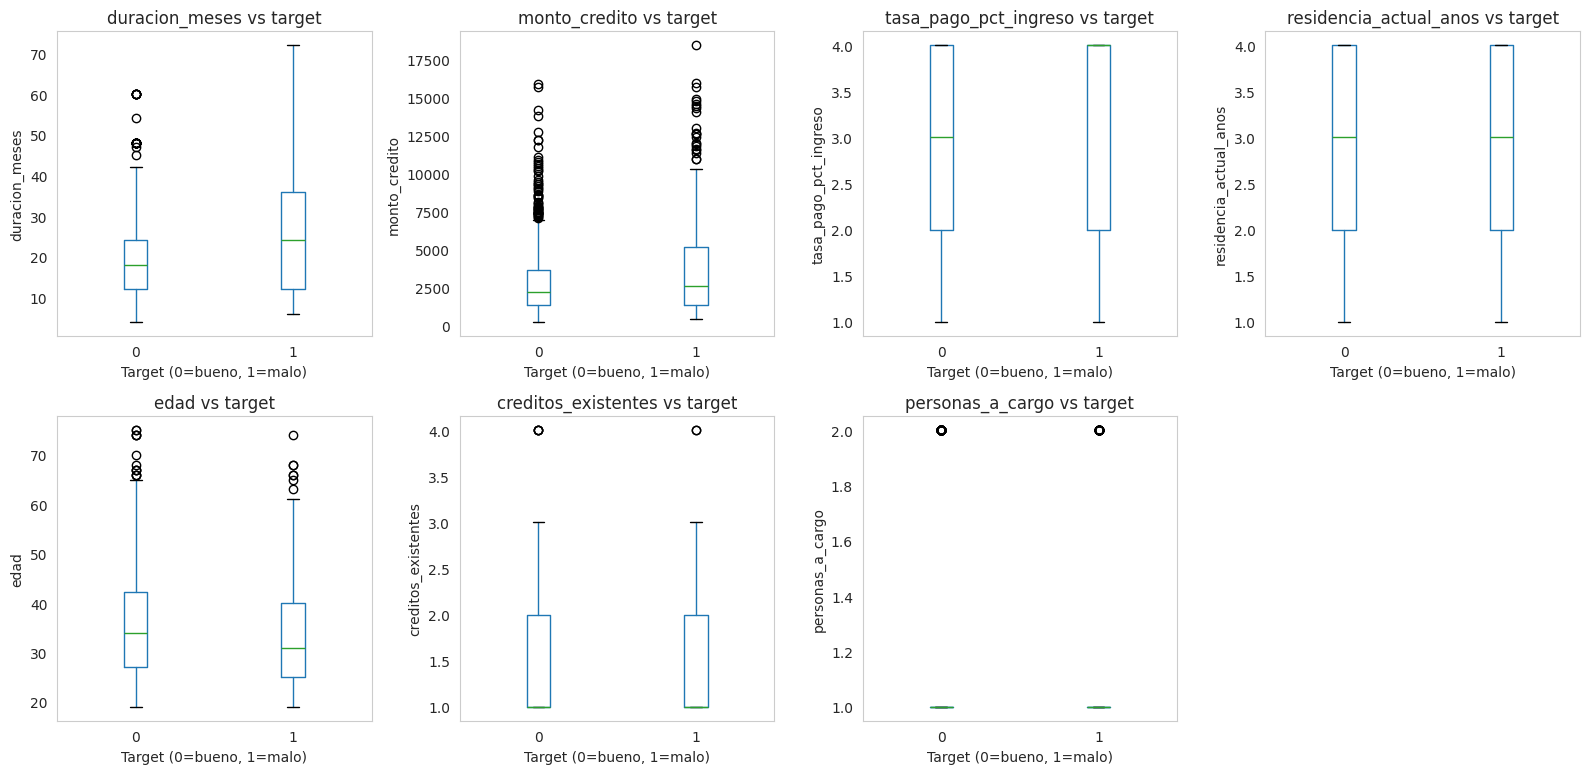

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    df.boxplot(column=col, by="target", ax=axes[i], grid=False)
    axes[i].set_title(f"{col} vs target")
    axes[i].set_xlabel("Target (0=bueno, 1=malo)")
    axes[i].set_ylabel(col)

for j in range(len(numericas), len(axes)):
    axes[j].axis("off")

plt.suptitle("")
plt.tight_layout()
plt.show()

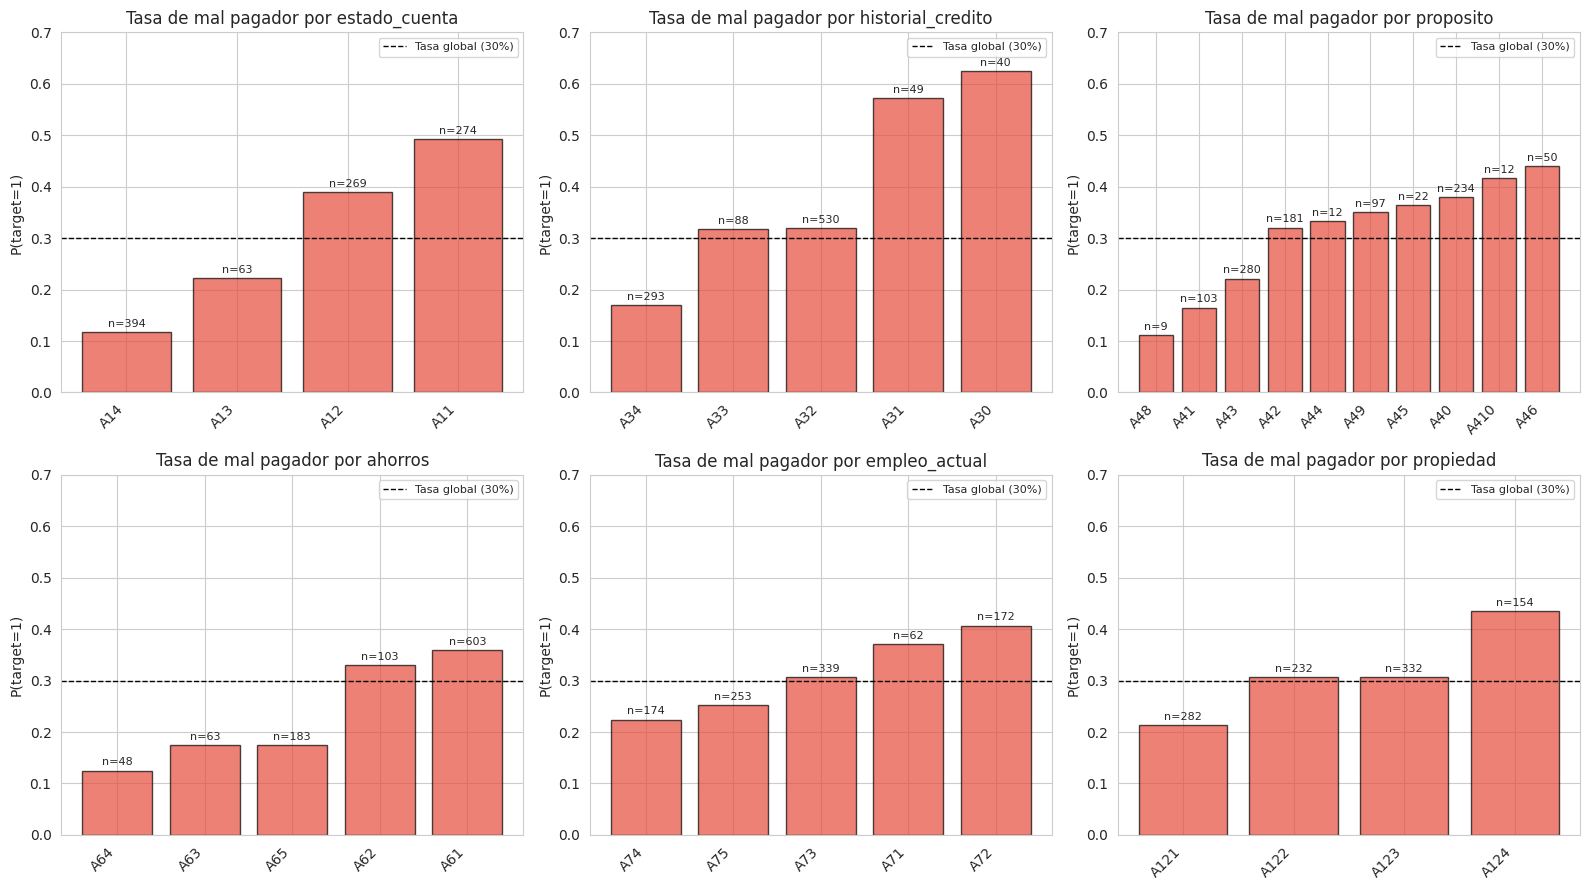

In [9]:
cats_clave = [
    "estado_cuenta",      # estado de cuenta corriente (predictor fuerte clásico)
    "historial_credito",  # historial pasado
    "proposito",          # para qué piden el crédito
    "ahorros",            # cuánto tienen ahorrado
    "empleo_actual",      # estabilidad laboral
    "propiedad",          # qué tipo de propiedad tienen
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cats_clave):
    # Tasa de mal pagador por categoría
    tasa_malo = df.groupby(col)["target"].mean().sort_values()
    counts = df[col].value_counts().reindex(tasa_malo.index)

    bars = axes[i].bar(
        range(len(tasa_malo)),
        tasa_malo.values,
        color="#e74c3c",
        alpha=0.7,
        edgecolor="black"
    )
    axes[i].axhline(0.3, color="black", linestyle="--", linewidth=1, label="Tasa global (30%)")
    axes[i].set_xticks(range(len(tasa_malo)))
    axes[i].set_xticklabels(tasa_malo.index, rotation=45, ha="right")
    axes[i].set_title(f"Tasa de mal pagador por {col}")
    axes[i].set_ylabel("P(target=1)")
    axes[i].set_ylim(0, 0.7)
    axes[i].legend(fontsize=8)

    # Anotar el n de cada barra
    for j, (bar, n) in enumerate(zip(bars, counts.values)):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"n={n}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

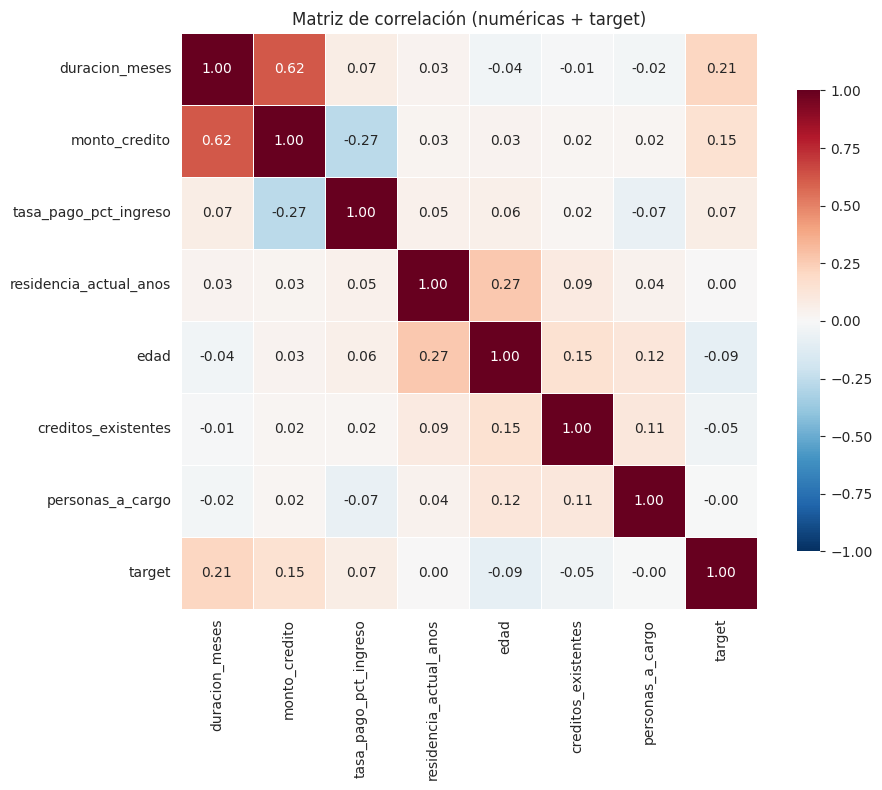

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df[numericas + ["target"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Matriz de correlación (numéricas + target)")
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import chi2_contingency

resultados_chi2 = []

for col in categoricas:
    tabla = pd.crosstab(df[col], df["target"])
    chi2, p_value, dof, _ = chi2_contingency(tabla)
    resultados_chi2.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p_value,
        "significativa (p<0.05)": p_value < 0.05
    })

chi2_df = pd.DataFrame(resultados_chi2).sort_values("chi2", ascending=False)
chi2_df.round(4)

,variable,chi2,p_value,significativa (p<0.05)
0,estado_cuenta,123.7209,0.0000,True
1,historial_credito,61.6914,0.0000,True
3,ahorros,36.0989,0.0000,True
2,proposito,33.3564,0.0001,True
7,propiedad,23.7196,0.0000,True
4,empleo_actual,18.3683,0.0010,True
9,vivienda,18.1998,0.0001,True
8,otros_planes_pago,12.8392,0.0016,True
5,estado_civil_sexo,9.6052,0.0222,True
6,deudores_garantes,6.6454,0.0361,True
